In [1]:
from sklearn.datasets import make_regression
import numpy as np

In [2]:
X, y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1, noise=80, random_state=13)

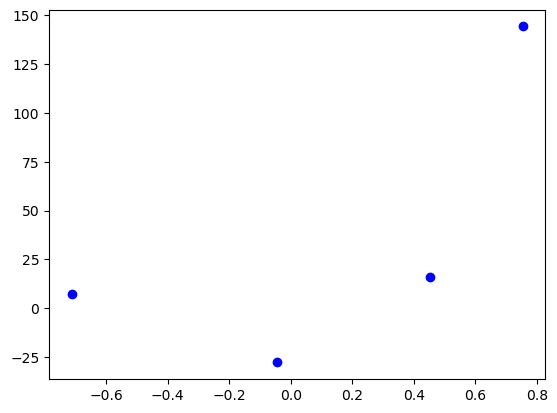

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X, y, color='blue', label='Data points')

# lets apply OLS

In [4]:
from sklearn.linear_model import LinearRegression

In [5]:
reg = LinearRegression()
reg.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
reg.coef_

array([78.35063668])

In [7]:
reg.intercept_

np.float64(26.15963284313262)

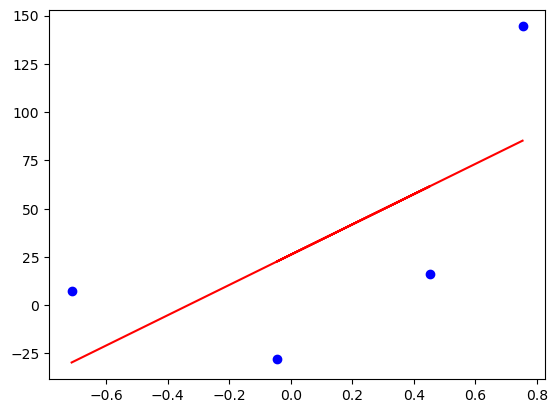

In [8]:
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, reg.predict(X), color='red', label='Regression line')

# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0

In [9]:
y_pred = (78.35*X + 0.0).reshape(4)
# y_pred = (78.35*X + 100).reshape(4)

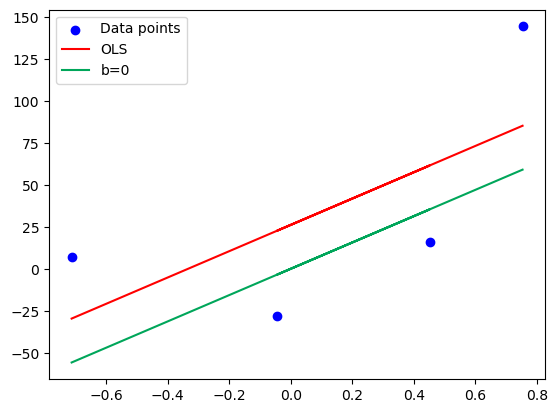

In [10]:
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, reg.predict(X), color='red', label='OLS')
plt.plot(X, y_pred, color='#00a65a', label='b=0')
# plt.plot(X, y_pred, color='#00a65a', label='b=100')

plt.legend()
plt.show()

In [11]:
m = 78.35
b = 0
# b = 100
# Iteration 1
loss_slope = -2 * np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(-209.27763408209216)

In [12]:
# Lets take learning rate = 0.1
lr = 0.1

step_size = lr * loss_slope
step_size

np.float64(-20.927763408209216)

In [13]:
# Calculating the new intercept
b = b - step_size
b

np.float64(20.927763408209216)

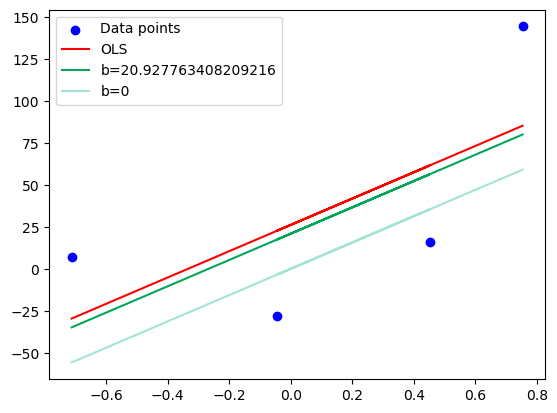

In [14]:
y_pred1 = (78.35*X + b).reshape(4)

plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, reg.predict(X), color='red', label='OLS')
plt.plot(X, y_pred1, color='#00a65a', label='b={}'.format(b))
# plt.plot(X, y_pred, color='#A3E4D7', label='b=100')
plt.plot(X, y_pred, color='#A3E4D7', label='b=0')

plt.legend()
plt.show()

In [15]:
# Iteration 2
loss_slope = -2 * np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(-41.85552681641843)

In [16]:
step_size = lr * loss_slope
step_size

np.float64(-4.185552681641844)

In [17]:
b = b - step_size
b

np.float64(25.11331608985106)

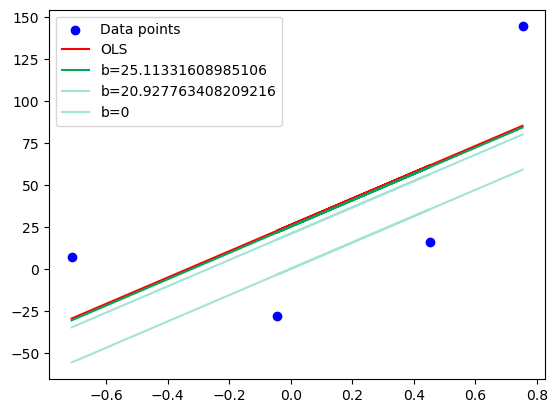

In [18]:
y_pred2 = ((78.35*X) +b).reshape(4)

plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, reg.predict(X), color='red', label='OLS')
plt.plot(X, y_pred2, color='#00a65a', label='b={}'.format(b))
plt.plot(X, y_pred1, color='#A3E4D7', label='b=20.927763408209216')
plt.plot(X, y_pred, color='#A3E4D7', label='b=0')
plt.legend()
plt.show()

In [19]:
# Iteration 3
loss_slope = -2 * np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(-8.371105363283675)

In [20]:
step_size = lr * loss_slope
step_size

np.float64(-0.8371105363283675)

In [21]:
b = b - step_size
b

np.float64(25.95042662617943)

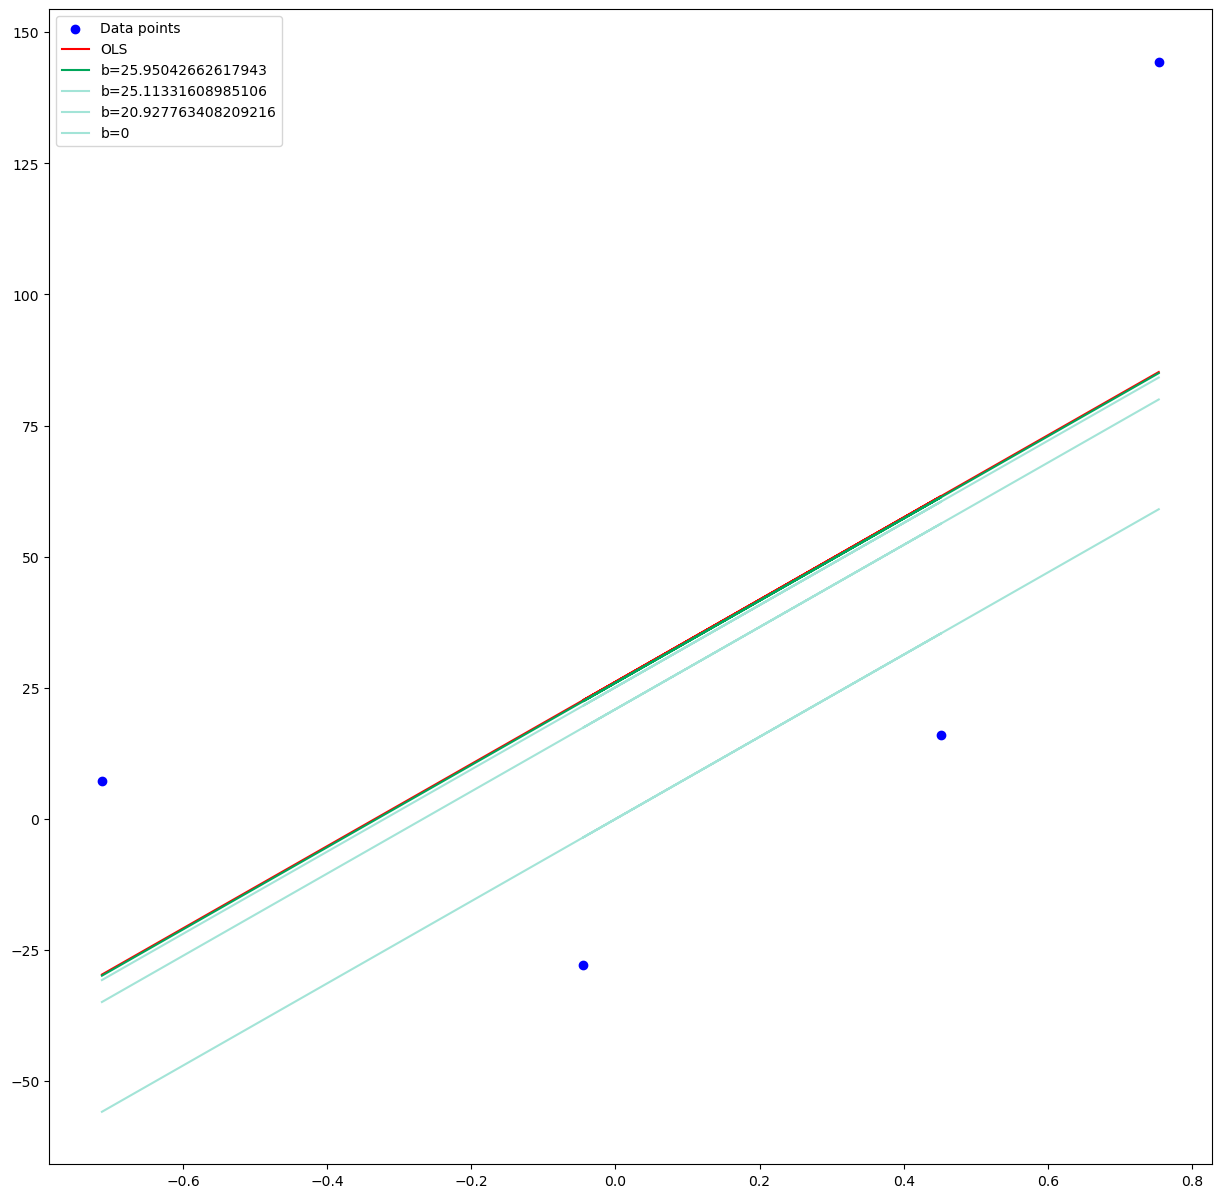

In [22]:
y_pred3 = ((78.35*X) +b).reshape(4)

plt.figure(figsize=(15,15))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, reg.predict(X), color='red', label='OLS')
plt.plot(X, y_pred3, color='#00a65a', label='b={}'.format(b))
plt.plot(X, y_pred2, color='#A3E4D7', label='b=25.11331608985106')
plt.plot(X, y_pred1, color='#A3E4D7', label='b=20.927763408209216')
plt.plot(X, y_pred, color='#A3E4D7', label='b=0')
plt.legend()
plt.show()

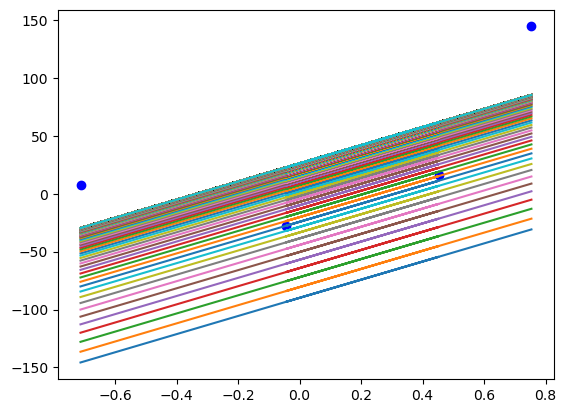

In [26]:
b = -100
m = 78.35
lr = 0.01

epochs = 10000

for i in range(epochs):
    loss_slope = -2 * np.sum(y-m*X.ravel()-b)
    b = b - (lr * loss_slope)

    y_pred = (78.35*X + b)
    plt.plot(X, y_pred)

plt.scatter(X, y, color='blue', label='Data points')